In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as img

I0000 00:00:1783889510.882033  159483 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783889510.914121  159483 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1783889512.546983  159483 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


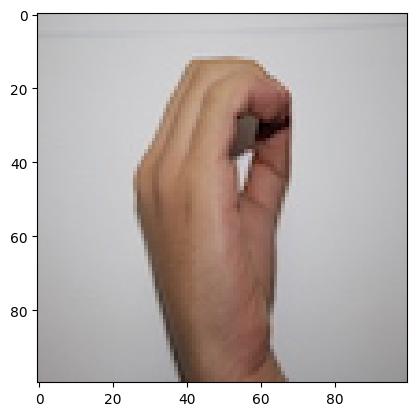

In [2]:
# Verificiar el dataset
imagen = img.imread('Dataset-Combinado/0/IMG_1148.JPG')
plt.imshow(imagen)
plt.show()

<BarContainer object of 10 artists>

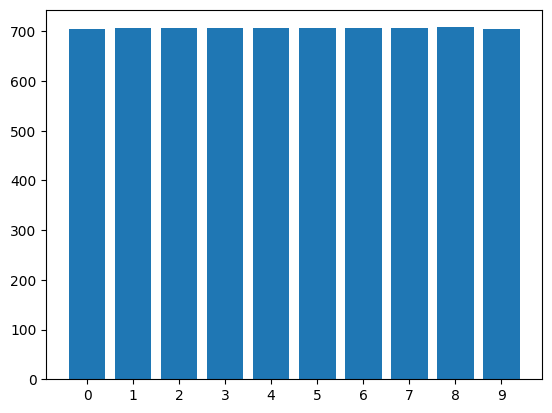

In [3]:
import os 
# Análisis descriptivo con gráficos
ruta_base = 'Dataset-Combinado/'
clases = sorted(os.listdir(ruta_base)) # Devuelve una lista con todas las rutas dentro de Dataset ej: ['0', '1', '2', '3', ...]

# Crear listas donde guardar los nombres de cada clase y la cantidad en cada una
nombres = []
cantidad = []

# Recorrer las subcarpetas y guardar la cantidad y nombres en las listas.
for clase in clases:
    ruta_clase = os.path.join(ruta_base, clase)
    cantidad.append(len(os.listdir(ruta_clase))) # Verificar cuantos archivos hay en la ruta de ruta_clase, que seria inicialmente Sign-Language-Digits-Dataset/Dataset/0, contarlos y agregarlos a la lista cantidad
    nombres.append(clase)

# Graficar con plt.bar
plt.bar(nombres, cantidad)

# El dataset contiene 7062 imágenes distribuidas en 10 clases (~700 c/u), como muestra el gráfico de barras. La distribución es prácticamente uniforme, por lo que el conjunto está balanceado.

In [4]:
# Determinar los datos para entrenamiento, validación y prueba.
datos_train = tf.keras.utils.image_dataset_from_directory(
    'Dataset-Combinado/',
    image_size=(150,150),
    batch_size=32,
    seed=42,
    validation_split=0.3,
    subset='training'
)

datos_restantes = tf.keras.utils.image_dataset_from_directory(
    'Dataset-Combinado/',
    image_size=(150,150),
    batch_size=32,
    seed=42,
    validation_split=0.3,
    subset='validation'
)  # Usar las imagenes en el mismo orden, no varian.

val_batches = tf.data.experimental.cardinality(datos_restantes)
datos_val = datos_restantes.take(val_batches // 2)
datos_test = datos_restantes.skip(val_batches // 2) # metodo skip para que no sean los mismos que datos_val


Found 7062 files belonging to 10 classes.
Using 4944 files for training.


I0000 00:00:1783889522.349737  159483 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1127 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060, pci bus id: 0000:01:00.0, compute capability: 8.9


Found 7062 files belonging to 10 classes.
Using 2118 files for validation.


In [5]:
# Normalizar
datos_train = datos_train.map(lambda x, y: (x / 255.0, y))
datos_val = datos_val.map(lambda x, y: (x / 255.0, y))
datos_test = datos_test.map(lambda x, y: (x / 255.0, y))

In [6]:
tf.random.set_seed(42) # Fijamos una seed de 42, para que todos los modelos entrenados para el taller partan con la misma base, y asi poder compararlos con los demás.

# Crear modelo
modelo_dropout = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(150,150,3)),
    # Implementar data augmentation (rotar las imagenes y hacer zoom para tener más variantes)
    tf.keras.layers.RandomRotation(0.05), # 15 grados aprox
    tf.keras.layers.RandomZoom(0.1), # 10% zoom
    tf.keras.layers.RandomTranslation(0.1, 0.1),                 # mano descentrada
    tf.keras.layers.RandomBrightness((-0.1, 0.4), value_range=(0, 1)),   # sesgado a MÁS brillo
    tf.keras.layers.RandomContrast(0.4, value_range=(0, 1)),             # más variación de contraste
    # Capas convolucionales
    tf.keras.layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    
    # Aplanar para usar los datos en la capa Dense, que solo acepta datos de forma lineal (1D)
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=256, activation='relu'),
    tf.keras.layers.Dropout(0.5), # Se apaga el 50% de neuronas
    tf.keras.layers.Dense(units=10, activation='softmax')
])


In [7]:
modelo_dropout.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_rotation                 │ (None, 150, 150, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 150, 150, 3)    │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness               │ (None, 150, 150, 3)    │             0 │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 150, 150, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 82944)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    21,233,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,255,882 (81.08 MB)

 Trainable params: 21,255,882 (81.08 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Configurar como va a aprender la red
modelo_dropout.compile(loss='sparse_categorical_crossentropy', 
               optimizer='adam', 
               metrics=['accuracy'])

In [9]:
tensorboard_cb = tf.keras.callbacks.TensorBoard(log_dir='logs/dropout')

# Implementar early stopping para cuando el modelo ya no esté aprendiendo, este pare, cuando el loss de validación deje de mejorar.
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4, # Cuantos epochs espera sin mejora antes de parar
    restore_best_weights=True # Se queda con los pesos del mejor momento
)

modelo_dropout.fit(
    datos_train,
    validation_data=datos_val,
    epochs=100,
    callbacks=[early_stop, tensorboard_cb]
)

Epoch 1/100


I0000 00:00:1783889556.272941  159730 cuda_dnn.cc:461] Loaded cuDNN version 92300


  5/155 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.0899 - loss: 4.4655

W0000 00:00:1783889557.591133  159728 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 665.94MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


155/155 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.3414 - loss: 1.9512 - val_accuracy: 0.7311 - val_loss: 0.9013
Epoch 2/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.5977 - loss: 1.1655 - val_accuracy: 0.8485 - val_loss: 0.4622
Epoch 3/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.6847 - loss: 0.9001 - val_accuracy: 0.9223 - val_loss: 0.3124
Epoch 4/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.7259 - loss: 0.7854 - val_accuracy: 0.9366 - val_loss: 0.2784
Epoch 5/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.7696 - loss: 0.6764 - val_accuracy: 0.9384 - val_loss: 0.2338
Epoch 6/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.7933 - loss: 0.5800 - val_accuracy: 0.9517 - val_loss: 0.1785
Epoch 7/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.8085 - loss: 0.5518 - val_accuracy: 0.9593 - val_loss: 0.1712
Epoch 8/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.8204 - loss: 0.5232 - val_accuracy

In [10]:
# Testear
resultado = modelo_dropout.evaluate(datos_test)

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9972 - loss: 0.0192


In [11]:
# Guardar modelo
modelo_dropout.save('modelo_dropout.keras')

In [12]:
# Cargar modelo
modelo_cargado = tf.keras.models.load_model('modelo_dropout.keras')

In [13]:
# Uso de metricas precision y recall para falsos positivos y falsos negativos
y_true = []
y_pred = []

for imagenes, etiquetas in datos_test:
    probabilidades = modelo_cargado.predict(imagenes, verbose=0)
    predicciones = np.argmax(probabilidades, axis=1)
    y_pred.extend(predicciones)
    y_true.extend(etiquetas.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(y_true.shape, y_pred.shape)

(1062,) (1062,)


In [14]:
# Crear matriz de confusion, para determinar cuanto falla en predecir y en qué falla
matriz = tf.math.confusion_matrix(y_true, y_pred, num_classes=10)
print(matriz)

tf.Tensor(
[[ 94   0   0   0   0   0   0   0   0   0]
 [  0 101   0   0   0   0   0   0   0   0]
 [  0   0 108   0   0   0   0   0   0   0]
 [  0   0   0 101   0   0   0   0   0   0]
 [  0   0   0   0 125   0   1   0   0   0]
 [  0   0   0   0   0  94   0   0   0   0]
 [  0   0   0   0   0   0 104   0   0   0]
 [  0   0   0   0   0   0   0 119   0   0]
 [  0   0   0   0   0   0   0   0 108   1]
 [  0   0   0   0   0   0   0   0   1 105]], shape=(10, 10), dtype=int32)


In [15]:
# Automatizar la deteccion de las 10 categorias para ver si hay falsos positivos y falsos negativos en cada una y calcular con las fórmulas
m = matriz.numpy()
vp = np.diag(m) # Sacar los 10 números de la diagonal, que son los verdaderos positivos.
fila = m.sum(axis=1) # Sumar las fila para sacar el falso negativo con el verdadero positivo juntos.
columna = m.sum(axis=0) # Sumas las columnas para sacar el falso positivo con el verdadero positivo juntos.

# Calcular recall, precision y f1
recall = vp / fila
precision = vp / columna
f1 = 2 * (precision * recall) / (precision + recall)

for d in range (10):
    print(f"Dígito {d}: Precisión={precision[d]:.2f}  Recall={recall[d]:.2f}  F1={f1[d]:.2f}")

Dígito 0: Precisión=1.00  Recall=1.00  F1=1.00
Dígito 1: Precisión=1.00  Recall=1.00  F1=1.00
Dígito 2: Precisión=1.00  Recall=1.00  F1=1.00
Dígito 3: Precisión=1.00  Recall=1.00  F1=1.00
Dígito 4: Precisión=1.00  Recall=0.99  F1=1.00
Dígito 5: Precisión=1.00  Recall=1.00  F1=1.00
Dígito 6: Precisión=0.99  Recall=1.00  F1=1.00
Dígito 7: Precisión=1.00  Recall=1.00  F1=1.00
Dígito 8: Precisión=0.99  Recall=0.99  F1=0.99
Dígito 9: Precisión=0.99  Recall=0.99  F1=0.99
